# Predicting English Language Recall

## 1. The Data Analysis Problem
 
* **Dataset:** Duolingo Spaced Repetition Dataset
* **Purpose:** To predict whether a language learner will successfully recall a word during a practice session, based on their historical interaction data and the spacing effect
* **Methodology:** This is a supervised binary classification task, contrasting a linear baseline model (Logistic Regression) against a non-linear algorithm (Random Forest)

Variable | Description
----------|--------------
p_recall | Proportion of exercises where word was correctly recalled 
timestamp | UNIX timestamp of the current practice
delta | Time (in seconds) since the last practice that included this word
user_id | Student user ID (anonymized)
learning_language | Language being learned
ui_language | User interface language (presumably native to the student)
lexeme_id | System ID for lexeme tag (i.e. word)
lexeme_string | String representation of lexeme tag for the word/concept being tested
history_seen | Total times user has seen the word prior to this practice
history_correct | Total times user has been correct prior to this practice
session_seen | Times the user saw the word during this practice
session_correct | Times the user got the word correct during this practice

## 2. Exploring the Data Using Pandas
### 2.1 Import modules and read data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns  
from matplotlib import pyplot as plt
%matplotlib inline


In [2]:
# Define file paths
input_file = 'learning_traces.zip'
output_file = 'english_learners_clean.csv'

# Set the chunk size 
chunk_size = 500000

# Create an empty list to hold the filtered dataframes
filtered_chunks = []

# Read through the file in chunks
for i, chunk in enumerate(pd.read_csv(input_file, compression='zip', chunksize=chunk_size)):
    
    # Filter for English learners only
    english_chunk = chunk[chunk['learning_language'] == 'en'].copy()
    
    # Append chunk to list
    filtered_chunks.append(english_chunk)
    
    print(f"Processed chunk {i + 1}...") # tracks progress of loading data

# Combine all the filtered chunks back into a single DataFrame
df_final = pd.concat(filtered_chunks, ignore_index=True) # throws away original row numbers and assigns new continuous row numbers
print(f"\nFinished. Filtered dataset has {len(df_final)} rows.")

# Save clean dataset to new CSV file
df_final.to_csv(output_file, index=False) # prevents from generating another set of row numbers

# Take random sample of 100k rows
df_sample = df_final.sample(n=100000, random_state=42).reset_index(drop=True) # sets random seed



Processed chunk 1...
Processed chunk 2...
Processed chunk 3...
Processed chunk 4...
Processed chunk 5...
Processed chunk 6...
Processed chunk 7...
Processed chunk 8...
Processed chunk 9...
Processed chunk 10...
Processed chunk 11...
Processed chunk 12...
Processed chunk 13...
Processed chunk 14...
Processed chunk 15...
Processed chunk 16...
Processed chunk 17...
Processed chunk 18...
Processed chunk 19...
Processed chunk 20...
Processed chunk 21...
Processed chunk 22...
Processed chunk 23...
Processed chunk 24...
Processed chunk 25...
Processed chunk 26...

Finished. Filtered dataset has 5014791 rows.


### 2.2 Exploring size of data and variable types

In [3]:
# Return shape of data
print(f"Dataset shape: {df_sample.shape}\n")

# Return columns and datatypes
print(df_sample.dtypes) # returns the datatype of each column


Dataset shape: (100000, 12)

p_recall             float64
timestamp              int64
delta                  int64
user_id                  str
learning_language        str
ui_language              str
lexeme_id                str
lexeme_string            str
history_seen           int64
history_correct        int64
session_seen           int64
session_correct        int64
dtype: object


### 2.3 Preliminary exploration of values in the data


In [4]:
# Display the first few rows of dataframe
print(df_sample.head())

# Return description of numerical values 
df_sample.describe()

   p_recall   timestamp    delta user_id learning_language ui_language  \
0      1.00  1362952016     2905  u:ikfY                en          es   
1      1.00  1362975377  2669830  u:e-5j                en          es   
2      1.00  1362419673    22283  u:eR9E                en          pt   
3      0.75  1362871952      290  u:d8aG                en          pt   
4      1.00  1362946854      269  u:iiFu                en          es   

                          lexeme_id             lexeme_string  history_seen  \
0  013847d897db3a32e994b9f6484ec486  necessary/necessary<adj>             3   
1  f42865f53c4d50746ed9bb08fe1fdfd8    white/white<adj><sint>            13   
2  4adf5cd40d521b02a9cc241bf3adc6bb     have/have<vblex><inf>            56   
3  d94aa893b5c536f2a4664637d9bec191              yes/yes<adv>            14   
4  62a992ac2a5f346b5796b3f14732130e       horses/horse<n><pl>             4   

   history_correct  session_seen  session_correct  
0                3          

,p_recall,timestamp,delta,history_seen,history_correct,session_seen,session_correct
count,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.896375,1.362591e+09,6.652469e+05,34.413680,29.918630,1.843700,1.667330
std,0.269660,2.928171e+05,1.998954e+06,198.577492,171.079074,1.426636,1.374671
min,0.000000,1.362083e+09,1.000000e+00,1.000000,1.000000,1.000000,0.000000
25%,1.000000,1.362348e+09,4.600000e+02,4.000000,3.000000,1.000000,1.000000
50%,1.000000,1.362594e+09,4.041400e+04,8.000000,7.000000,1.000000,1.000000
75%,1.000000,1.362845e+09,3.637755e+05,19.000000,17.000000,2.000000,2.000000
max,1.000000,1.363105e+09,2.904163e+07,12503.000000,11934.000000,20.000000,20.000000


In [5]:
# Return data types associated with each variable- check if pandas guessed correctly
df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   p_recall           100000 non-null  float64
 1   timestamp          100000 non-null  int64  
 2   delta              100000 non-null  int64  
 3   user_id            100000 non-null  str    
 4   learning_language  100000 non-null  str    
 5   ui_language        100000 non-null  str    
 6   lexeme_id          100000 non-null  str    
 7   lexeme_string      100000 non-null  str    
 8   history_seen       100000 non-null  int64  
 9   history_correct    100000 non-null  int64  
 10  session_seen       100000 non-null  int64  
 11  session_correct    100000 non-null  int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 9.2 MB


### 2.4 Distributions of categorical values


In [6]:
# Check how many unique users vs total rows of data 
n_unique_users = df_sample['user_id'].nunique() # number of unique users
n_total_rows = len(df_sample) 

print(f"Total traces: {n_total_rows}")
print(f"Unique users: {n_unique_users}")
print(f"Average traces per user: {n_total_rows / n_unique_users:.2f}") #

print('user_id is non-numeric and has {} unique values so we can drop it'
      .format(len(df_sample['user_id'].unique())))

df_sample = df_sample.drop(['user_id'], axis=1)

Total traces: 100000
Unique users: 23577
Average traces per user: 4.24
user_id is non-numeric and has 23577 unique values so we can drop it


In [7]:
# Check different user native languages
print("Languages in the current sample:")
print(df_sample['ui_language'].value_counts())

Languages in the current sample:
ui_language
es    72541
pt    19012
it     8447
Name: count, dtype: int64


In [8]:
# Check if Lexeme ID and String provide the same amount of unique information
print(f"Unique Lexeme IDs: {df_sample['lexeme_id'].nunique()}")
print(f"Unique Lexeme Strings: {df_sample['lexeme_string'].nunique()}")


Unique Lexeme IDs: 2156
Unique Lexeme Strings: 2156


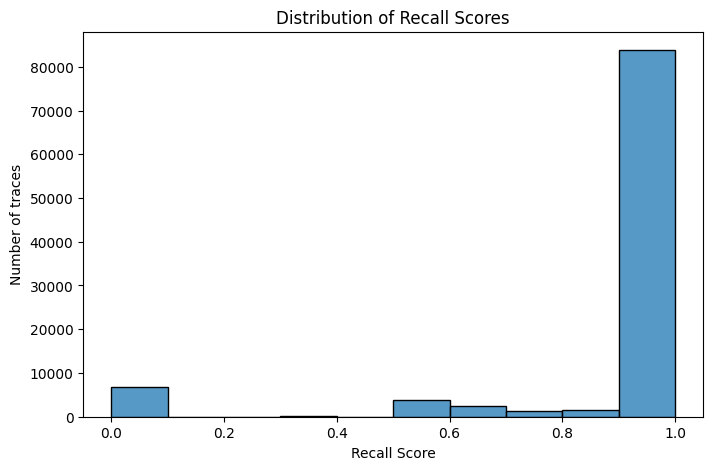

In [9]:
# Check distribution of p_recall
plt.figure(figsize=(8, 5))
sns.histplot(df_sample['p_recall'], bins=10) # divides into 10 equal bins

plt.title('Distribution of Recall Scores')
plt.xlabel('Recall Score')
plt.ylabel('Number of traces')
plt.show()

In [10]:
# Convert p_recall to binary target perfect_recall
df_sample['perfect_recall'] = (df_sample['p_recall'] == 1.0).astype(int)

# Check distribution of Perfect Recall
print('Values and counts for perfect_recall are:\n{}'.format(df_sample['perfect_recall'].value_counts()))
print('\nNormalised counts for perfect recall:\n{}'.format(df_sample['perfect_recall'].value_counts(normalize=True)))


Values and counts for perfect_recall are:
perfect_recall
1    83686
0    16314
Name: count, dtype: int64

Normalised counts for perfect recall:
perfect_recall
1    0.83686
0    0.16314
Name: proportion, dtype: float64


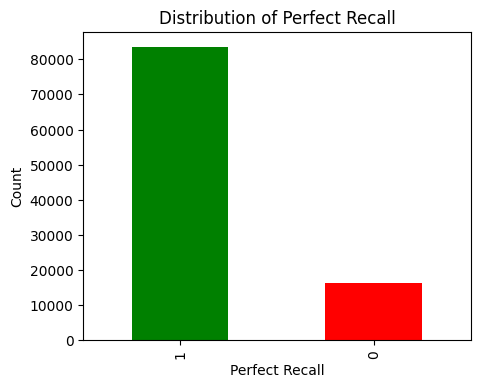

In [11]:
# Plot Perfect Recall counts
df_sample['perfect_recall'].value_counts().plot.bar(figsize=(5, 4), title='Distribution of Perfect Recall', color=['g', 'r'], 
                                                    ylabel = 'Count', xlabel= 'Perfect Recall')
plt.show()

In [12]:
# Check Top 10 words being practiced 
print("Top 10 most practiced words/lexemes:")
print(df_sample['lexeme_string'].value_counts().head(10)) # limits to top 10 values

Top 10 most practiced words/lexemes:
lexeme_string
a/a<det><ind><sg>                     2459
is/be<vbser><pri><p3><sg>             1974
eats/eat<vblex><pri><p3><sg>          1788
we/prpers<prn><subj><p1><mf><pl>      1402
are/be<vbser><pres>                   1389
eat/eat<vblex><pres>                  1369
they/prpers<prn><subj><p3><mf><pl>    1323
drink/drink<vblex><pres>              1234
and/and<cnjcoo>                       1202
man/man<n><sg>                        1200
Name: count, dtype: int64


### 2.5 Distributions of continuous variables


In [13]:
# Check the distribution of session repetitions
print("Number of times a word was seen in a single session:")
print(df_sample['session_seen'].value_counts().head(10))

# Light repetition of single words- most have 1-2 counts

Number of times a word was seen in a single session:
session_seen
1     57273
2     22313
3     10743
4      4972
5      2286
6       979
7       510
8       305
9       166
10      155
Name: count, dtype: int64


count    100000.000000
mean         34.413680
std         198.577492
min           1.000000
25%           4.000000
50%           8.000000
75%          19.000000
max       12503.000000
Name: history_seen, dtype: float64


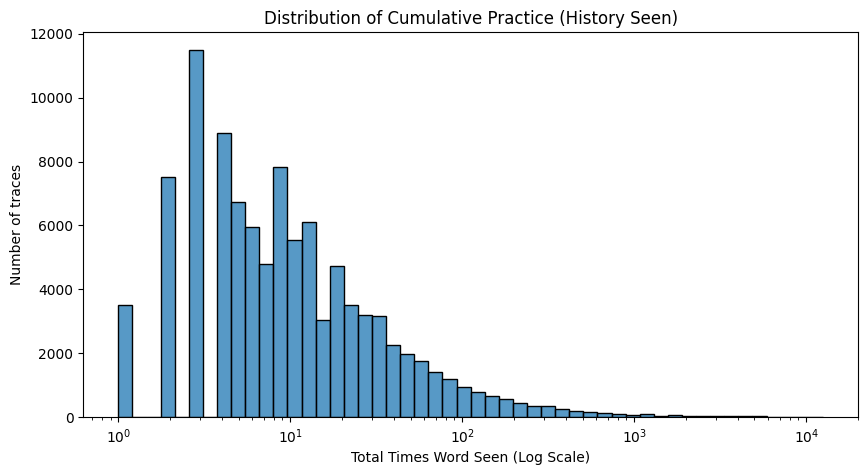

In [14]:
# Check the statistical spread of history
print(df_sample['history_seen'].describe())

# Visualise the distribution using a log scale 
plt.figure(figsize=(10, 5))
sns.histplot(df_sample['history_seen'], bins=50, log_scale=True)
plt.title('Distribution of Cumulative Practice (History Seen)')
plt.xlabel('Total Times Word Seen (Log Scale)')
plt.ylabel('Number of traces')
plt.show()

# Shows extreme positive skew

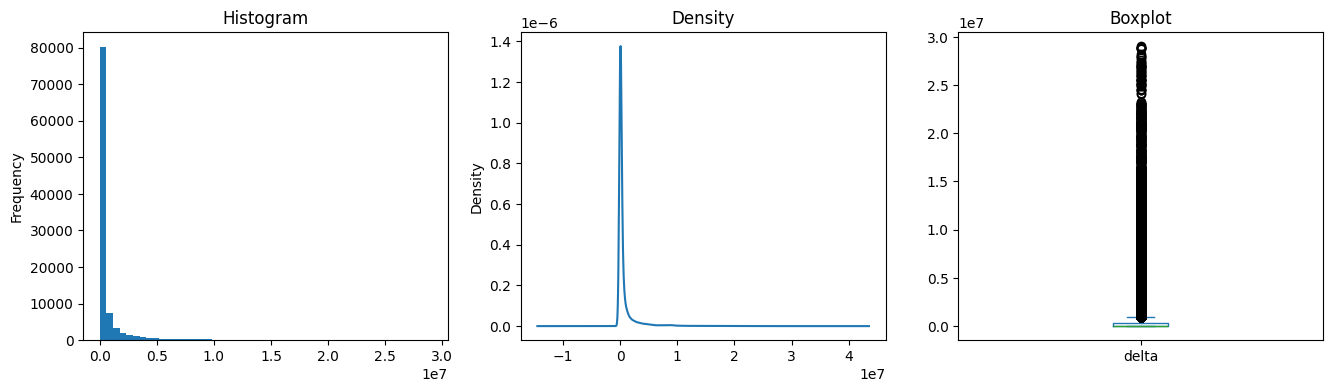

In [15]:
# Check distribution of Delta
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
df_sample['delta'].plot(kind='hist', bins=50, ax=axes[0], title="Histogram")
df_sample['delta'].plot(kind='density', ax=axes[1], title="Density")
df_sample['delta'].plot(kind='box', ax=axes[2], title="Boxplot")

plt.show()

### 2.6 Bivariate Analysis- Categorical variables

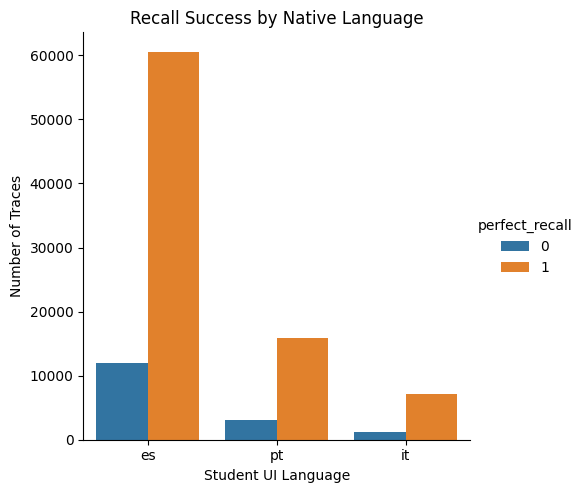

In [16]:

# Visualizing UI Language against Perfect recall
data_melted = pd.melt(df_sample, id_vars=['perfect_recall'], value_vars=['ui_language']) # anchors perfect_recall variable
g = sns.catplot(data=data_melted, kind='count', col='variable', x='value', hue='perfect_recall', sharex=False)
g.set_axis_labels(x_var='Student UI Language', y_var='Number of Traces') # change axis labels
plt.title('Recall Success by Native Language')
plt.show()


### 2.7 Bivariate Analysis- Continuous variables

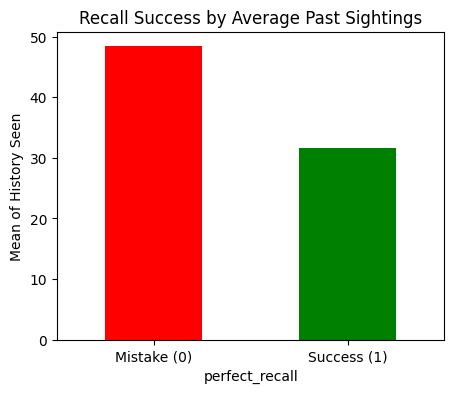

In [17]:
# Visualizing mean of History seen against Perfect Recall
df_sample.groupby('perfect_recall')['history_seen'].mean().plot(kind='bar', ylabel='Mean of History Seen', color=['r', 'g'], figsize=(5, 4))
plt.title('Recall Success by Average Past Sightings')
plt.xticks([0, 1], ['Mistake (0)', 'Success (1)'], rotation=0)
plt.show()

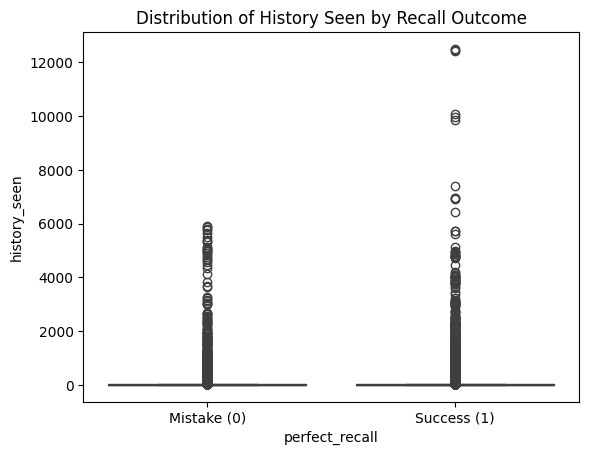

In [18]:
# Boxplot of history seen against perfect recall
sns.boxplot(x='perfect_recall', y='history_seen', data=df_sample)
plt.xticks([0, 1], ['Mistake (0)', 'Success (1)'])
plt.title('Distribution of History Seen by Recall Outcome')
plt.show()

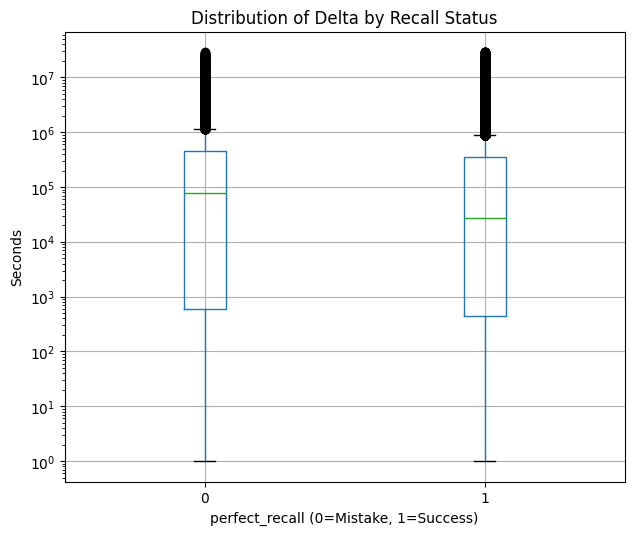

In [19]:
# Boxplot of Delta by Recall Status
# Shows spread of time for successes vs failures
df_sample.boxplot(column='delta', by='perfect_recall', figsize=(7, 6))

plt.title('Distribution of Delta by Recall Status')
plt.suptitle('') # removes default title
plt.xlabel('perfect_recall (0=Mistake, 1=Success)')
plt.ylabel('Seconds')
plt.yscale('log')
plt.show()
# Spacing effect- median delta higher for mistakes, lower of successes- lots of outliers

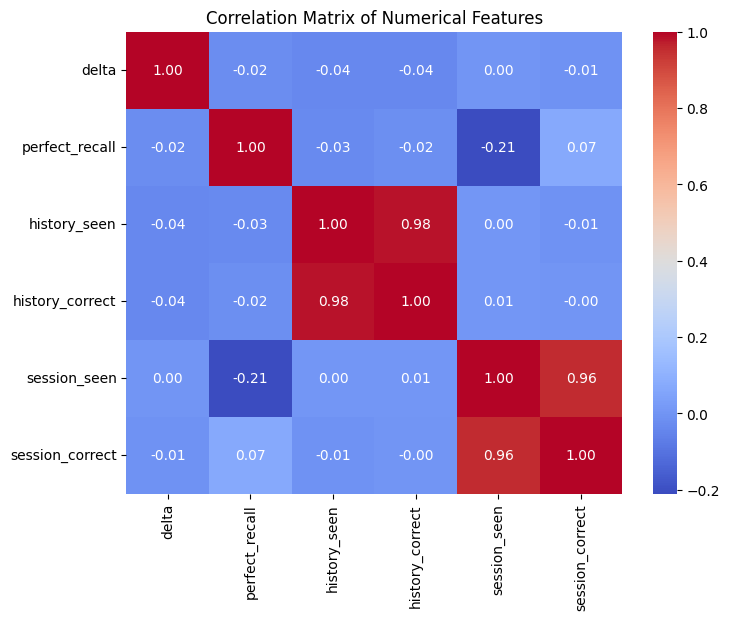

In [20]:
# Correlation check for continuous variables
numerical_cols = ['delta', 'perfect_recall', 'history_seen', 'history_correct', 'session_seen', 'session_correct'] # filters continuous variables
correlation_matrix = df_sample[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f") # visualise correlation matrix with numbers to 2dp
plt.title('Correlation Matrix of Numerical Features')
plt.show()

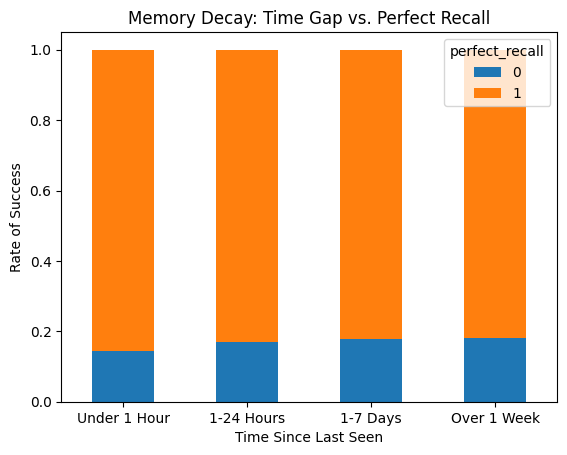

In [21]:
# Discretised Delta vs Perfect Recall
bins = [0, 3600, 86400, 604800, df_sample['delta'].max()]
labels = ['Under 1 Hour', '1-24 Hours', '1-7 Days', 'Over 1 Week']
df_sample['time_gap_category'] = pd.cut(df_sample['delta'], bins, labels=labels) # add discretised values as new column

time_recall = pd.crosstab(df_sample['time_gap_category'], df_sample['perfect_recall']) # get value combination counts
time_recall= time_recall.div(time_recall.sum(axis=1).astype(float), axis=0) # normalise counts
time_recall.plot(kind="bar", stacked=True, xlabel="Time Since Last Seen", ylabel="Rate of Success")
plt.title('Memory Decay: Time Gap vs. Perfect Recall')
plt.xticks(rotation=0) # stops labels rotating
plt.show()

In [22]:
# Calculate percentage of mistakes for each time bin
delta_percentages = pd.crosstab(df_sample['time_gap_category'], df_sample['perfect_recall'], normalize='index') * 100
print("Recall Success Percentages by Time Gap:")
print(delta_percentages)

Recall Success Percentages by Time Gap:
perfect_recall             0          1
time_gap_category                      
Under 1 Hour       14.417479  85.582521
1-24 Hours         17.071721  82.928279
1-7 Days           17.906752  82.093248
Over 1 Week        18.160190  81.839810


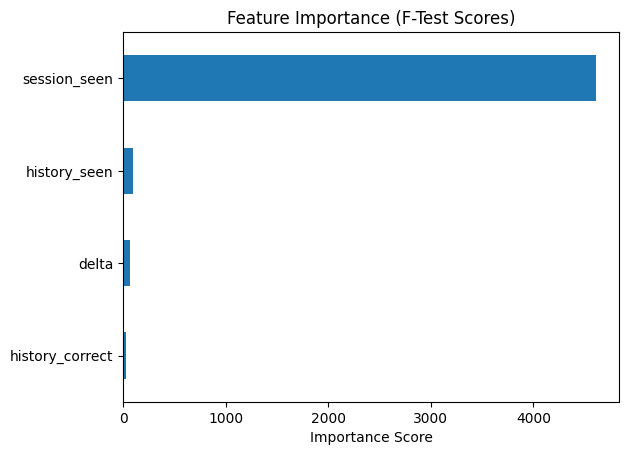

In [23]:
# Calculate F-test scores
from sklearn.feature_selection import SelectKBest, f_classif

X_num = df_sample[['history_seen', 'history_correct', 'session_seen', 'delta']] # filter numerical columns
y = df_sample['perfect_recall']

ftest = SelectKBest(score_func=f_classif, k='all').fit(X_num, y)
ftest_scores = pd.Series(data=ftest.scores_, index=X_num.columns).sort_values()

ftest_scores.plot(kind='barh', title='Feature Importance (F-Test Scores)')
plt.xlabel('Importance Score')
plt.show()

## 3. Preprocessing data using Pandas
### 3.1 Missing value imputation

In [24]:
# Check for missing values
print(df_sample.isnull().sum())

p_recall             0
timestamp            0
delta                0
learning_language    0
ui_language          0
lexeme_id            0
lexeme_string        0
history_seen         0
history_correct      0
session_seen         0
session_correct      0
perfect_recall       0
time_gap_category    0
dtype: int64


In [25]:
# Log Transform for Delta to handle extreme skewness
df_sample['delta_log'] = np.log(df_sample['delta'])

# Feature Engineering: Create history_success_rate 
df_sample['history_success_rate'] = df_sample['history_correct'] / df_sample['history_seen']

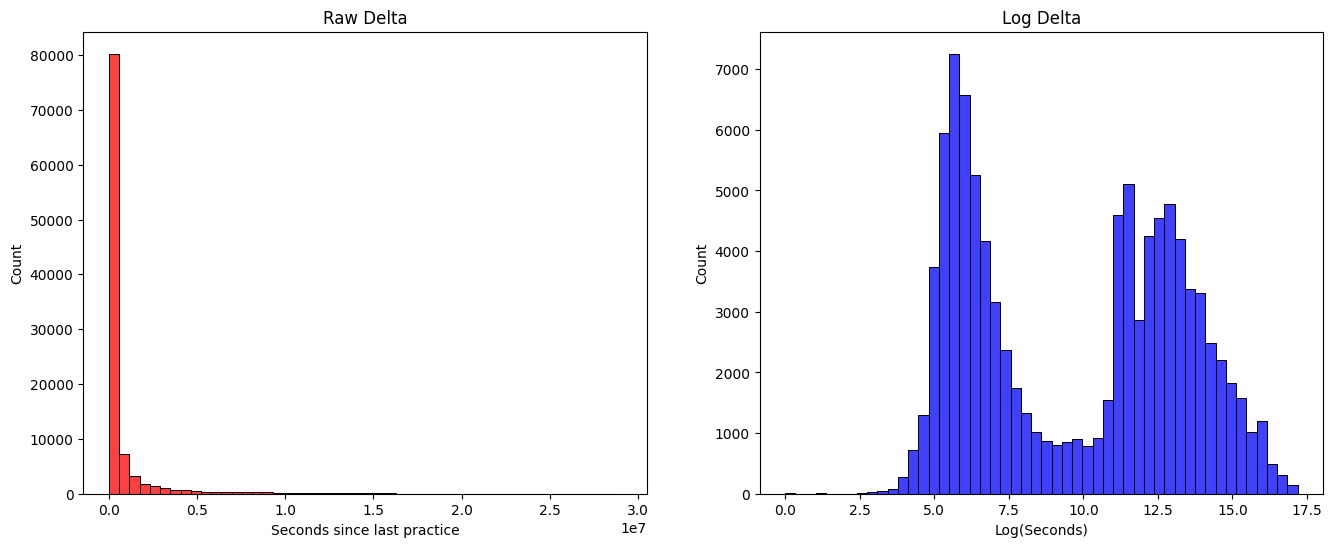

In [26]:
# Compare Raw Delta to Log Delta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Raw Delta
sns.histplot(df_sample['delta'], bins=50, ax=ax1, color='r')
ax1.set_title('Raw Delta')
ax1.set_xlabel('Seconds since last practice')

# Plot Log Delta
sns.histplot(np.log(df_sample['delta']), bins=50, ax=ax2, color='b') 
ax2.set_title('Log Delta')
ax2.set_xlabel('Log(Seconds)')

plt.show()

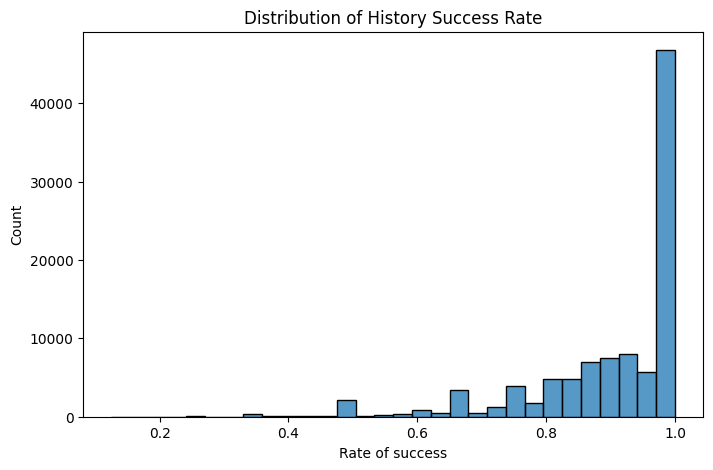

In [27]:
# Visualise History Success Rate distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_sample['history_success_rate'], bins=30)
plt.title('Distribution of History Success Rate')
plt.xlabel('Rate of success')
plt.show()

In [28]:
# Drop redundant variables
cols_to_drop = ['lexeme_id', 'lexeme_string', 'learning_language', 
                'history_correct', 'history_seen', 'delta', 'p_recall','timestamp', 'session_seen', 'session_correct',
                'time_gap_category'] # also drop bins made for charts 

df_clean = df_sample.drop(columns=cols_to_drop)
df_clean.head()

,ui_language,perfect_recall,delta_log,history_success_rate
0,es,1,7.974189,1.000000
1,es,1,14.797525,0.923077
2,pt,1,10.011579,0.875000
3,pt,0,5.669881,0.642857
4,es,1,5.594711,1.000000


In [29]:
# Convert ui_language into dummy variables
df_final = pd.get_dummies(df_clean, columns=['ui_language'], drop_first=True)

df_final.head()

,perfect_recall,delta_log,history_success_rate,ui_language_it,ui_language_pt
0,1,7.974189,1.000000,False,False
1,1,14.797525,0.923077,False,False
2,1,10.011579,0.875000,False,True
3,0,5.669881,0.642857,False,True
4,1,5.594711,1.000000,False,False


In [30]:
print(df_final.columns.tolist())

['perfect_recall', 'delta_log', 'history_success_rate', 'ui_language_it', 'ui_language_pt']


## 4. Feature Selection

### 4.1 Look at correlations between each pair of variables using Pandas

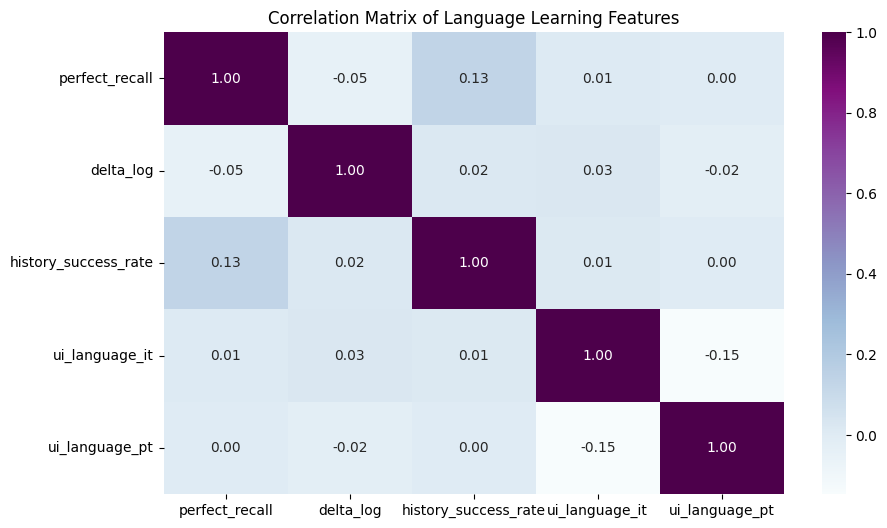

In [31]:
# Calculate correlation matrix for final features
corr = df_final.corr() 

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="BuPu", fmt=".2f")  
plt.title('Correlation Matrix of Language Learning Features')
plt.show()

In [32]:
# Test strength of remaining features
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.ensemble import ExtraTreesClassifier

# Define X and y
X = df_final.drop('perfect_recall', axis=1)
y = df_final['perfect_recall']

# Chi-squared test
chi2 = SelectKBest(score_func=chi2, k='all').fit(X, y)
chi2_sorted = pd.Series(data=chi2.scores_, index=X.columns).sort_values()

# ANOVA F-value test (ftest)
ftest = SelectKBest(score_func=f_classif, k='all').fit(X, y)
ftest_sorted = pd.Series(data=ftest.scores_, index=X.columns).sort_values()

# Mutual Information Test
mitest = SelectKBest(score_func=mutual_info_classif, k='all').fit(X, y)
mitest_sorted = pd.Series(data=mitest.scores_, index=X.columns).sort_values()

# ExtraTreesClassifier
xtrees = ExtraTreesClassifier(random_state=42).fit(X, y)
xtrees_sorted = pd.Series(data=xtrees.feature_importances_, index=X.columns).sort_values()

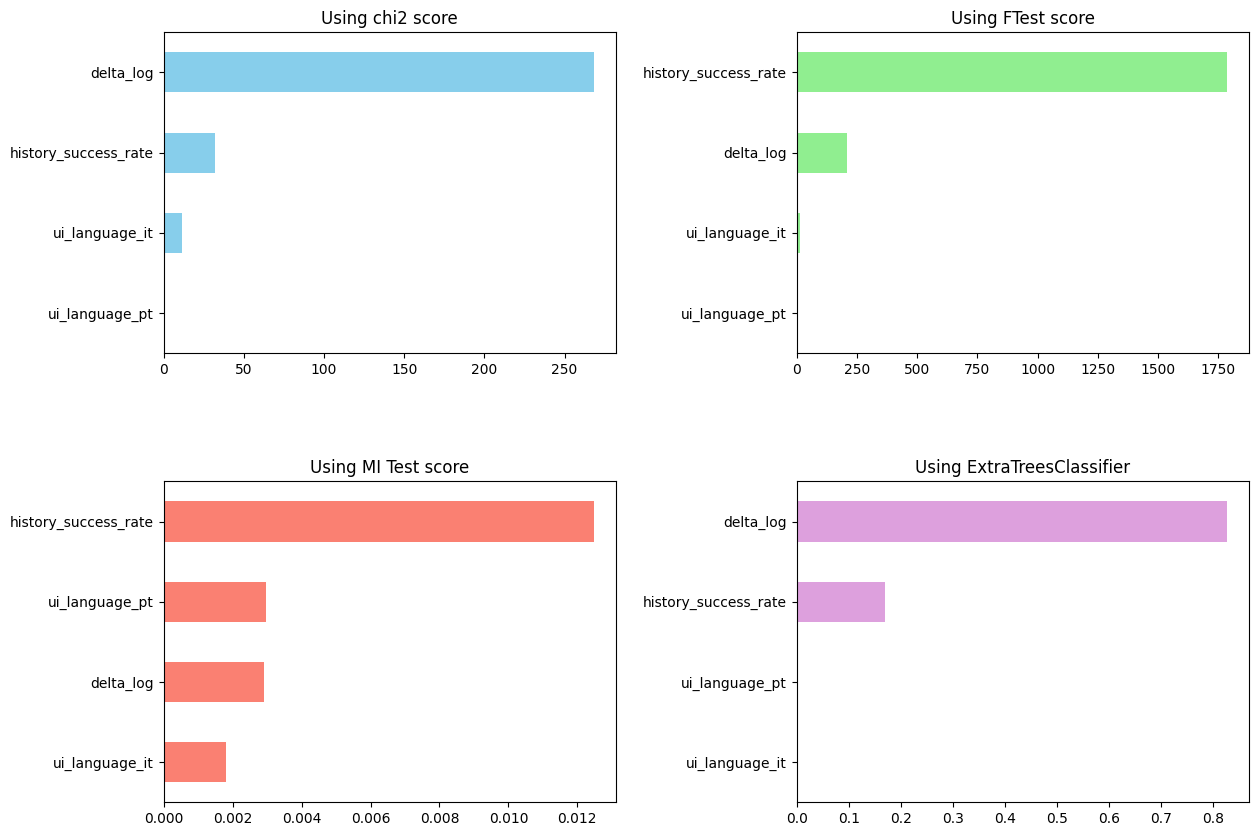

In [33]:
# Plot strength of remaining features
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

chi2_sorted.plot(kind='barh', ax=axes[0, 0], color='skyblue', title='Using chi2 score')
ftest_sorted.plot(kind='barh', ax=axes[0, 1], color='lightgreen', title='Using FTest score')
mitest_sorted.plot(kind='barh', ax=axes[1, 0], color='salmon', title='Using MI Test score')
xtrees_sorted.plot(kind='barh', ax=axes[1, 1], color='plum', title='Using ExtraTreesClassifier')

plt.show()

## 5. Prediction and Evaluation using Scikit-Learn

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def train_and_evaluate_recall(model, X, y):
    """
    Train and evaluate a classification model on training data
    and produce accuracy metrics for a separate test set
    with internal scaling to prevent data leakage.
    """
    print('\nResults from algorithm {}:'.format(model))

    # Split data into train and test (80% train, 20% test)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Apply feature scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw) # fit and transform the feature
    X_test = scaler.transform(X_test_raw) 
    
    # Cross-Validation on scaled data
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print('Mean cross-validation accuracy is {:.3f} with SD {:.3f}'
          .format(np.mean(scores), np.std(scores)))

    # Fit model on training data and check for overfitting
    learnt_model = model.fit(X_train, y_train)
    print('\nAccuracy on training data is {:.3f}\n'.format(model.score(X_train, y_train)))
    
    # Predict target values from test set
    y_pred = model.predict(X_test)
    print('Test data metrics: accuracy={:.3f}, f1={:.3f}, precision={:.3f}, recall={:.3f}'
          .format(accuracy_score(y_true=y_test, y_pred=y_pred),
                  f1_score(y_true=y_test, y_pred=y_pred),
                  precision_score(y_true=y_test, y_pred=y_pred),
                  recall_score(y_true=y_test, y_pred=y_pred)))
        
    # Draw Confusion Matrix
    cm = confusion_matrix(y_true=y_test, y_pred=y_pred)
    plt.figure(figsize=(3, 3))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
                xticklabels=['Forgot (0)', 'Recall (1)'], 
                yticklabels=['Forgot (0)', 'Recall (1)'])
    ax.set_xlabel('Predicted Status')
    ax.set_ylabel('Actual Status')
    plt.show()
    
    return learnt_model

### Logistic Regression


Results from algorithm LogisticRegression(max_iter=200):
Mean cross-validation accuracy is 0.836 with SD 0.000

Accuracy on training data is 0.836

Test data metrics: accuracy=0.841, f1=0.913, precision=0.841, recall=1.000


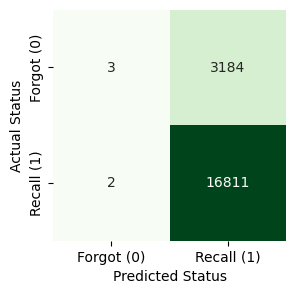

In [35]:
from sklearn.linear_model import LogisticRegression
lr_model = train_and_evaluate_recall(LogisticRegression(max_iter=200), X, y)

### Random Forest


Results from algorithm RandomForestClassifier(class_weight='balanced', random_state=42):
Mean cross-validation accuracy is 0.748 with SD 0.002

Accuracy on training data is 0.970

Test data metrics: accuracy=0.751, f1=0.853, precision=0.844, recall=0.863


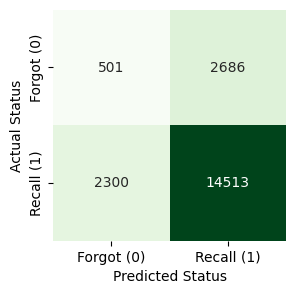

In [36]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = train_and_evaluate_recall(RandomForestClassifier(random_state=42, class_weight='balanced'), X, y) 

### Random Forest- limit growth of trees


Results from algorithm RandomForestClassifier(class_weight='balanced', max_depth=12, n_jobs=-1,
                       random_state=42):
Mean cross-validation accuracy is 0.674 with SD 0.003

Accuracy on training data is 0.716

Test data metrics: accuracy=0.670, f1=0.786, precision=0.864, recall=0.721


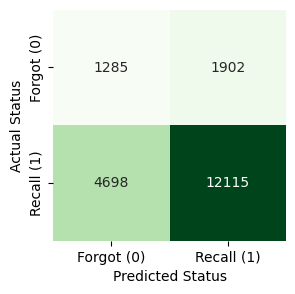

In [ ]:
# Random forest- limit depth
rf_model_balanced = train_and_evaluate_recall(
    RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=12, n_jobs=-1), X, y) 

## 6. Select best hyperparameter values using cross-validation


Max Depth 2: CV Accuracy = 0.641
Max Depth 4: CV Accuracy = 0.627
Max Depth 6: CV Accuracy = 0.628
Max Depth 8: CV Accuracy = 0.637
Max Depth 10: CV Accuracy = 0.649
Max Depth 12: CV Accuracy = 0.669
Max Depth 14: CV Accuracy = 0.694
Max Depth 16: CV Accuracy = 0.719


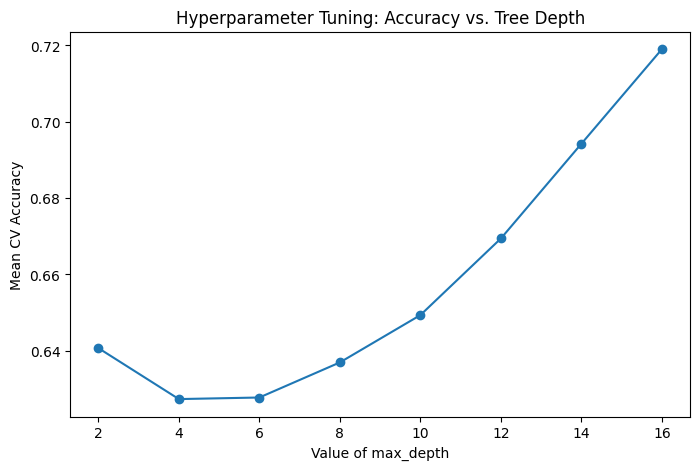

In [ ]:
def train_model(algorithm, hyperparams, X, y):
    """
    Use cross-validation to determine model accuracy for a 
    specified algorithm, hyperparameters, features and target
    variables.
    """
    # Instantiate the model with the passed hyperparameters
    model = algorithm(**hyperparams)

    # Perform cross-validation
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')

    # Fit model to supplied  data
    learnt_model = model.fit(X, y)

    # Return mean accuracy over all CV folds
    return (np.mean(scores), learnt_model)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a range for max depth
depth_values = [2 * i for i in range(1, 9)]
depth_accuracy = []
for depth in depth_values:
    acc, _ = train_model(RandomForestClassifier, {'max_depth': depth, 'class_weight': 'balanced', 'random_state': 42}, X_train, y_train)
    depth_accuracy.append(acc)
    print(f"Max Depth {depth}: CV Accuracy = {acc:.3f}")

# Plotting results
plt.figure(figsize=(8, 5))
plt.plot(depth_values, depth_accuracy, marker='o')
plt.ylabel('Mean CV Accuracy')
plt.xlabel('Value of max_depth')
plt.title('Hyperparameter Tuning: Accuracy vs. Tree Depth')
plt.show()

Final Training Accuracy: 0.716
Test data metrics: Accuracy: 0.670, F1: 0.786, Precision: 0.865, Recall: 0.720


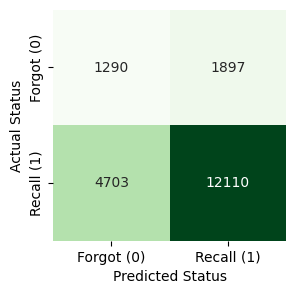

In [39]:
# Train final model with chosen best hyperparameter
best_depth = 12
train_accuracy, best_rf_model = train_model(RandomForestClassifier, {'max_depth': best_depth, 'class_weight': 'balanced', 'random_state': 42}, X_train, y_train)

train_score = best_rf_model.score(X_train, y_train)
print(f"Final Training Accuracy: {train_score:.3f}")

# Check accuracy on test set
y_pred = best_rf_model.predict(X_test)
print('Test data metrics: Accuracy: {:.3f}, F1: {:.3f}, Precision: {:.3f}, Recall: {:.3f}'
      .format(accuracy_score(y_test, y_pred),
              f1_score(y_test, y_pred),
              precision_score(y_test, y_pred),
              recall_score(y_test, y_pred)))

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(3, 3))
ax = sns.heatmap(cm, annot=True, fmt='d',cmap='Greens', cbar=False,
            xticklabels=['Forgot (0)', 'Recall (1)'],
            yticklabels=['Forgot (0)', 'Recall (1)'])
ax.set_xlabel('Predicted Status')
ax.set_ylabel('Actual Status')
plt.show()